# Data Profiler Practical

**Subject:** Data Preprocessing and Feature Engineering

I am using a customer purchase dataset for the practical work. The notebook covers data loading, checking, cleaning, EDA and data profiling.


## 1. Libraries

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import requests
import sqlite3

print("All required libraries are ready.")



All required libraries are ready.


## 2. CSV file

In [3]:
df = pd.read_csv("../data/customers.csv")
print("CSV data:")
df.head()


CSV data:


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,F001,24.0,Female,29000.0,2,3800,Jaipur,2025-01-18
1,F002,32.0,Male,51000.0,7,14200,Indore,2025-02-04
2,F003,27.0,Female,36000.0,4,6900,Udaipur,2025-02-27
3,F004,NaN,Male,47000.0,6,11800,Bhopal,2025-03-12
4,F005,39.0,Female,68000.0,11,24500,Pune,2025-03-29


## 3. JSON file

In [4]:
json_data = pd.read_json("../data/customers.json")
print("JSON data:")
json_data.head()


JSON data:


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,F001,24.0,Female,29000.0,2,3800,Jaipur,2025-01-18
1,F002,32.0,Male,51000.0,7,14200,Indore,2025-02-04
2,F003,27.0,Female,36000.0,4,6900,Udaipur,2025-02-27
3,F004,NaN,Male,47000.0,6,11800,Bhopal,2025-03-12
4,F005,39.0,Female,68000.0,11,24500,Pune,2025-03-29


In [5]:
print("JSON rows:", len(json_data))
print("JSON columns:", len(json_data.columns))


JSON rows: 16
JSON columns: 8


## 4. SQL database

In [6]:
connection = sqlite3.connect("../data/customers.db")

database_data = pd.read_sql_query(
    "SELECT * FROM customers",
    connection
)

database_data.head()


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,F001,24.0,Female,29000.0,2,3800,Jaipur,2025-01-18
1,F002,32.0,Male,51000.0,7,14200,Indore,2025-02-04
2,F003,27.0,Female,36000.0,4,6900,Udaipur,2025-02-27
3,F004,NaN,Male,47000.0,6,11800,Bhopal,2025-03-12
4,F005,39.0,Female,68000.0,11,24500,Pune,2025-03-29


In [7]:
sql_result = pd.read_sql_query(
    "SELECT CustomerID, Income, Orders, Purchases FROM customers WHERE Orders >= 7",
    connection
)

sql_result


,CustomerID,Income,Orders,Purchases
0,F002,51000.0,7,14200
1,F005,68000.0,11,24500
2,F006,76000.0,9,27500
3,F008,54000.0,8,15900
4,F010,63000.0,10,23000
5,F011,49000.0,7,15100
6,F013,72000.0,12,29000
7,F008,54000.0,8,15900


In [8]:
connection.close()

## 5. REST API

In [9]:
api_url = "https://jsonplaceholder.typicode.com/users"

api_response = requests.get(api_url, timeout=15)

print("Status code:", api_response.status_code)


Status code: 200


In [10]:
users = api_response.json()
api_df = pd.DataFrame(users)

print("API records:", len(api_df))
api_df.head()


API records: 10


,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,"{'street': 'Hoeger Mall', 'suite': 'Apt. 692',...",493-170-9623 x156,kale.biz,"{'name': 'Robel-Corkery', 'catchPhrase': 'Mult..."
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,"{'street': 'Skiles Walks', 'suite': 'Suite 351...",(254)954-1289,demarco.info,"{'name': 'Keebler LLC', 'catchPhrase': 'User-c..."


## 6. Checking the dataset

In [11]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst rows:")
display(df.head())


Shape: (16, 8)

Columns: ['CustomerID', 'Age', 'Gender', 'Income', 'Orders', 'Purchases', 'City', 'SignupDate']

First rows:


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,F001,24.0,Female,29000.0,2,3800,Jaipur,2025-01-18
1,F002,32.0,Male,51000.0,7,14200,Indore,2025-02-04
2,F003,27.0,Female,36000.0,4,6900,Udaipur,2025-02-27
3,F004,NaN,Male,47000.0,6,11800,Bhopal,2025-03-12
4,F005,39.0,Female,68000.0,11,24500,Pune,2025-03-29


In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  16 non-null     object 
 1   Age         15 non-null     float64
 2   Gender      15 non-null     object 
 3   Income      15 non-null     float64
 4   Orders      16 non-null     int64  
 5   Purchases   16 non-null     int64  
 6   City        16 non-null     object 
 7   SignupDate  16 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.1+ KB


In [13]:
df.describe(include="all")


,CustomerID,Age,Gender,Income,Orders,Purchases,City,SignupDate
count,16,15.000000,15,15.000000,16.000000,16.0000,16,16
unique,15,NaN,2,NaN,NaN,NaN,9,15
top,F008,NaN,Male,NaN,NaN,NaN,Delhi,2025-05-24
freq,2,NaN,8,NaN,NaN,NaN,3,2
mean,NaN,32.733333,NaN,49200.000000,6.625000,14312.5000,NaN,NaN
std,NaN,7.205818,NaN,15803.254638,2.941088,8082.7285,NaN,NaN
min,NaN,22.000000,NaN,24000.000000,2.000000,3800.0000,NaN,NaN
25%,NaN,27.500000,NaN,38000.000000,4.750000,8250.0000,NaN,NaN
50%,NaN,32.000000,NaN,49000.000000,6.500000,13500.0000,NaN,NaN
75%,NaN,37.500000,NaN,58500.000000,8.250000,17675.0000,NaN,NaN


## 7. Missing values and duplicate rows

In [14]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
CustomerID    0
Age           1
Gender        1
Income        1
Orders        0
Purchases     0
City          0
SignupDate    0
dtype: int64

Duplicate rows: 1


## 8. Cleaning

In [15]:
cleaned = df.copy()

cleaned["Age"] = cleaned["Age"].fillna(cleaned["Age"].median())
cleaned["Income"] = cleaned["Income"].fillna(cleaned["Income"].median())
cleaned["Gender"] = cleaned["Gender"].fillna(cleaned["Gender"].mode()[0])

print("Rows before:", len(cleaned))
cleaned = cleaned.drop_duplicates()
print("Rows after:", len(cleaned))

print("\nMissing values after cleaning:")
print(cleaned.isna().sum())


Rows before: 16
Rows after: 15

Missing values after cleaning:
CustomerID    0
Age           0
Gender        0
Income        0
Orders        0
Purchases     0
City          0
SignupDate    0
dtype: int64


I kept CustomerID in the cleaned dataset because it is useful for identifying records. For numerical analysis/model features, I can leave the identifier out.


In [16]:
analysis_data = cleaned.drop(columns=["CustomerID"])
analysis_data.head()


,Age,Gender,Income,Orders,Purchases,City,SignupDate
0,24.0,Female,29000.0,2,3800,Jaipur,2025-01-18
1,32.0,Male,51000.0,7,14200,Indore,2025-02-04
2,27.0,Female,36000.0,4,6900,Udaipur,2025-02-27
3,32.0,Male,47000.0,6,11800,Bhopal,2025-03-12
4,39.0,Female,68000.0,11,24500,Pune,2025-03-29


## 9. Univariate analysis

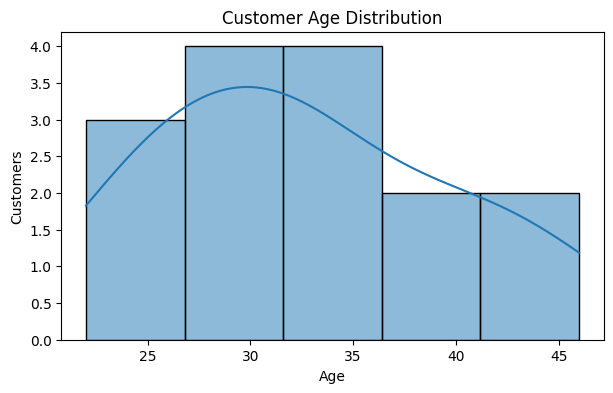

In [17]:
plt.figure(figsize=(7, 4))
sns.histplot(cleaned["Age"], kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.show()


**Observation:** This graph shows the age range of the customers in the dataset.

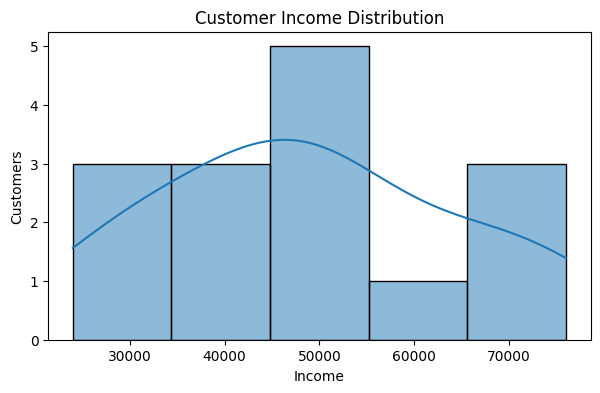

In [18]:
plt.figure(figsize=(7, 4))
sns.histplot(cleaned["Income"], kde=True)
plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Customers")
plt.show()


**Observation:** The graph gives an idea of how income values are distributed.

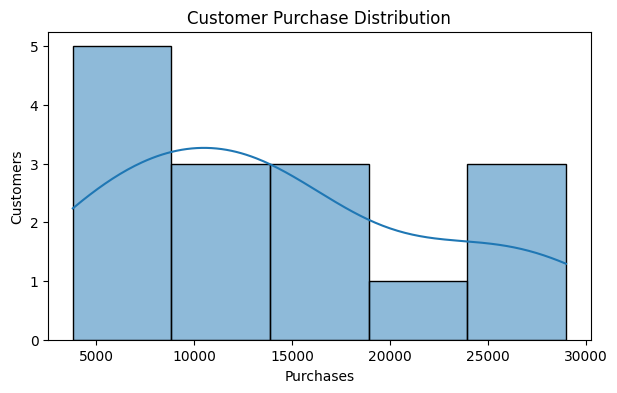

In [19]:
plt.figure(figsize=(7, 4))
sns.histplot(cleaned["Purchases"], kde=True)
plt.title("Customer Purchase Distribution")
plt.xlabel("Purchases")
plt.ylabel("Customers")
plt.show()


**Observation:** This graph shows the spread of purchase amounts.

## 10. Bivariate analysis

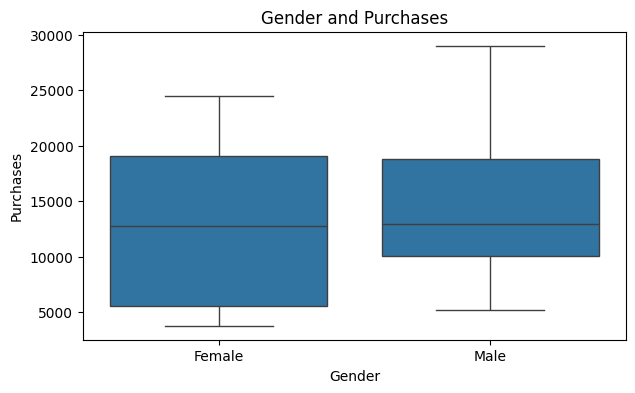

In [20]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=cleaned, x="Gender", y="Purchases")
plt.title("Gender and Purchases")
plt.xlabel("Gender")
plt.ylabel("Purchases")
plt.show()


**Observation:** The box plot is used to compare purchase amounts between the gender groups.

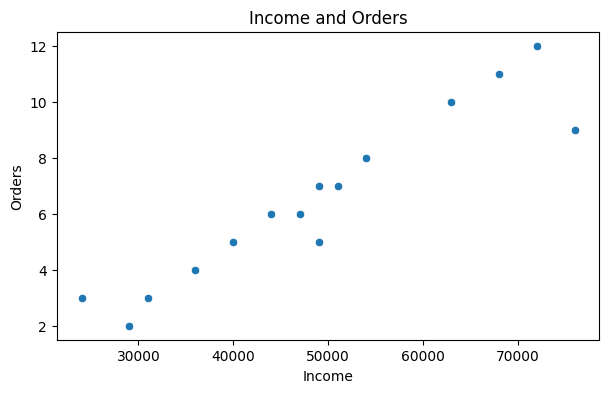

In [21]:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=cleaned, x="Income", y="Orders")
plt.title("Income and Orders")
plt.xlabel("Income")
plt.ylabel("Orders")
plt.show()


**Observation:** The scatter plot helps check whether income and order count appear to move together.

## 11. Multivariate analysis

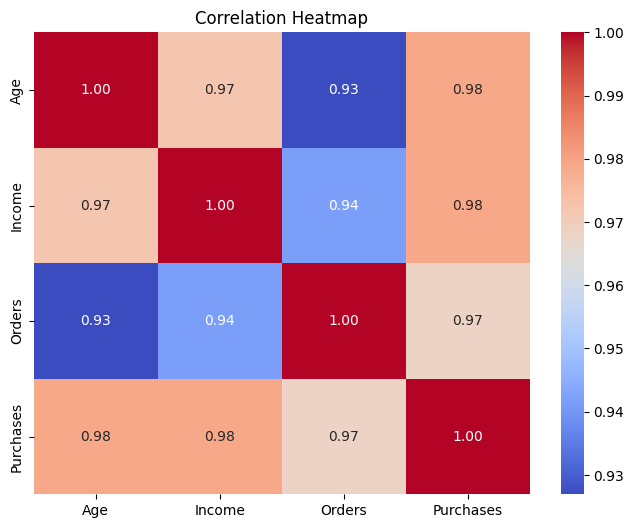

In [22]:
numbers = cleaned.select_dtypes(include="number")

plt.figure(figsize=(8, 6))
sns.heatmap(numbers.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


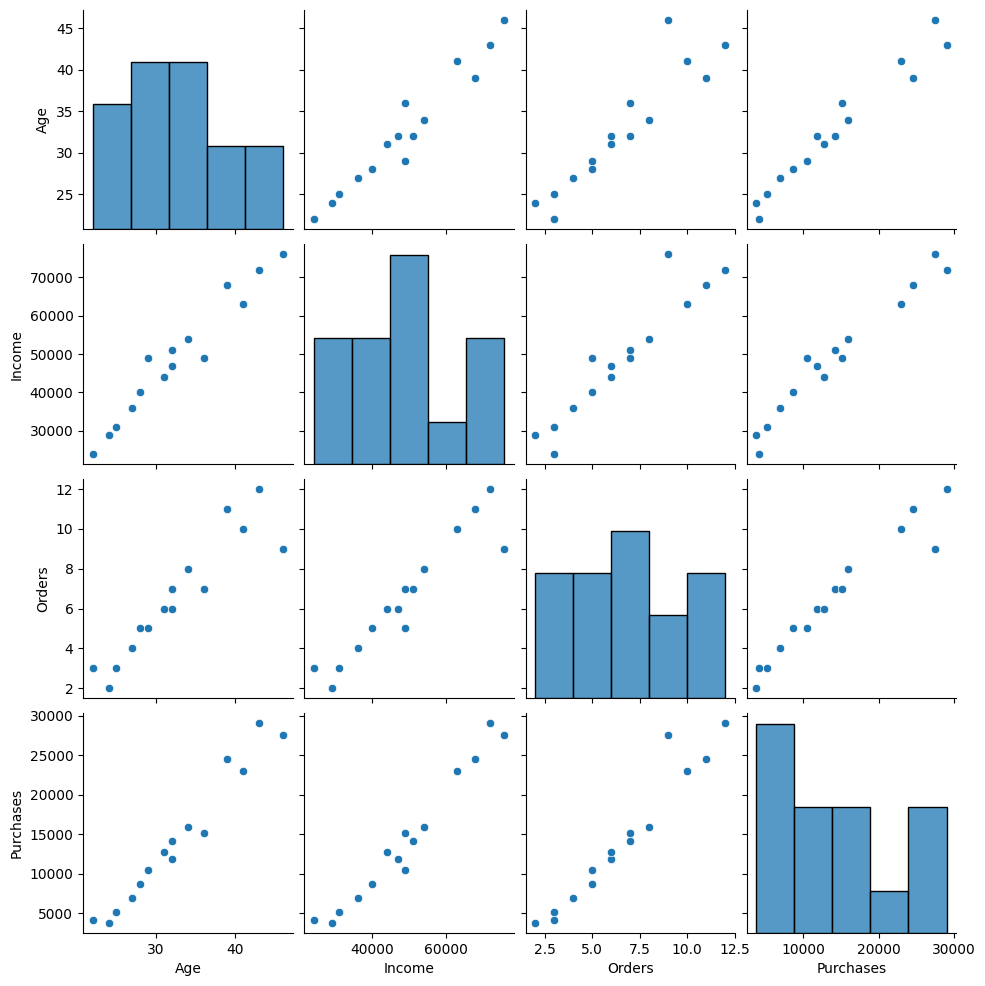

In [23]:
sns.pairplot(cleaned[["Age", "Income", "Orders", "Purchases"]])
plt.show()


**Observation:** The heatmap gives correlation values and the pair plot shows several numerical variables together.

## 12. Automated profiling report

In [24]:
import os
import sweetviz as sv

os.makedirs("../reports", exist_ok=True)

report = sv.analyze(cleaned)

report.show_html(
    "../reports/profiling_report.html",
    open_browser=False
)

print("Profiling report created.")

c:\Users\RNW\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report ../reports/profiling_report.html was generated.
Profiling report created.


## 13. Machine learning problem

A possible problem is **Customer Purchase Prediction**.

Inputs can be Age, Gender, Income and Orders. The target is Purchases. Since the target is numerical, this can be treated as a regression problem.


## 14. Conclusion

In this practical I loaded customer data from different sources, checked its structure, handled missing and duplicate data, created the required EDA graphs and generated an automated profiling report.
